In [1]:
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-$(python -c 'import torch; print(torch.__version__)').html -q
!pip install torchmetrics -q
!pip install thop -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# PyTorch Geometric imports
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, knn_graph, BatchNorm
from torch_geometric.data import Data, Batch
from torchvision.models import vit_b_16, ViT_B_16_Weights

# Metrics and Logging
from torchmetrics.classification import MulticlassAUROC
from thop import profile # <-- CORRECTED IMPORT
import csv
import os

import torchvision
import torchvision.transforms as transforms
import numpy as np
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.5 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 68.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 90.8 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.4 MB/s eta 0:00:00a 0:00:01
Using device: cuda


In [2]:
class vit_knn_gat(nn.Module):
    def __init__(self, patch_size, depth, dim=128, k=9, num_classes=10, heads=4):
        super().__init__()
        self.patch_size=patch_size
        self.dim=dim
        self.k=k
        weights = ViT_B_16_Weights.IMAGENET1K_V1
        self.vit = vit_b_16(weights=weights)
        self.embed_dim = 768
        self.depth = depth
        self.heads = heads
        
        self.conv1 = GATConv(self.embed_dim, (dim*2)//heads, heads=heads, dropout=0.1)
        self.conv2 = GATConv(dim*2, (dim)//heads, heads=heads, dropout=0.1)
        self.head = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(dim, num_classes)
        )
        self.dropout = nn.Dropout(0.1)
        self.bn1 = BatchNorm(dim*2)
        self.bn2 = BatchNorm(dim)

    def forward(self, img):
        with torch.no_grad():
            x = self.vit.conv_proj(img)
            x = x.flatten(2).transpose(1, 2)
            n = x.shape[0]
            batch_class_token = self.vit.class_token.expand(n, -1, -1)
            x = torch.cat([batch_class_token, x], dim=1)
            x = x + self.vit.encoder.pos_embedding
            for i in range(self.depth):
                x = self.vit.encoder.layers[i](x)
            x = self.vit.encoder.ln(x)
        x = x[:, 1:]
        B, N, C = x.shape
        x_flat = x.reshape(-1, C)
        batch_vec = torch.arange(B, device=x.device).repeat_interleave(N)
        edge_index = knn_graph(x_flat, k=self.k, batch=batch_vec, loop=True)
        h = self.conv1(x_flat, edge_index)
        h = self.bn1(h)
        h = F.relu(h)
        h = F.dropout(h, p=0.2, training=self.training)
        
        h=self.conv2(h, edge_index)
        h = self.bn2(h)
        h = F.relu(h)
        
        h_batch = global_mean_pool(h, batch_vec)
        out = self.head(h_batch)
        return out

results_filename = 'diagnostics_vit_knn_gcn.csv'
with open(results_filename, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "train_acc", "test_loss", "test_acc", "test_auc", "avg_flops_g"])

In [3]:
def train_loop(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for img, label in loader:
        img, label = img.to(device), label.to(device)
        optimizer.zero_grad()
        output = model(img)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * img.size(0)
        pred = output.argmax(dim=1)
        correct += (pred==label).sum().item()
        total += img.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def test_loop(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds = []
    all_labels = []
    for img, label in loader:
        img, label = img.to(device), label.to(device)
        output = model(img)
        loss = criterion(output, label)
        total_loss += loss.item() * img.size(0)
        pred = output.argmax(dim=1)
        correct += (pred==label).sum().item()
        total += img.size(0)
        all_preds.append(F.softmax(output, dim=1))
        all_labels.append(label)
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return total_loss/total, correct/total, all_preds, all_labels
    

In [4]:
batch_size = 32
patch_size = 8
node_feature_dim = 3*patch_size*patch_size
hidden_dim = 128
k=15
epochs = 15

model = vit_knn_gat(patch_size=patch_size, depth=2, dim=hidden_dim, k=k, num_classes=10, heads=4).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
criterion = nn.CrossEntropyLoss()
auroc_metric = MulticlassAUROC(num_classes=10, average="macro", thresholds=None).to(device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Added Color Jitter
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 237MB/s]  
100%|██████████| 170M/170M [00:02<00:00, 57.0MB/s] 


In [5]:
try:
    batch_data = next(iter(testloader))
    images = batch_data[0].to(device) 
    
    # ViT is heavy, disable verbose to avoid spamming layer info
    macs, params = profile(model, inputs=(images,), verbose=False)
    total_flops_g = macs / 1e9
    avg_flops_g = total_flops_g / batch_size
    print(f"Average FLOPs per image: {avg_flops_g:.4f} GFLOPs")
except Exception as e:
    print(f"FLOPs Error: {e}")
    avg_flops_g = 0
    
best_acc = 0
print("\n--- Starting Training ---")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(model, tqdm(trainloader, desc='Training'), optimizer, criterion)
    test_loss, test_acc, test_preds, test_labels = test_loop(model, tqdm(testloader, desc='Testing'), criterion)
    test_auc = auroc_metric(test_preds, test_labels).item()
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), f'best_gcn_model.pth')
    print(f"\nEpoch {epoch+1}/{epochs} Summary:")
    print(f'  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f} | Test AUC: {test_auc:.4f} | Best Acc: {best_acc:.4f}')
    with open(results_filename, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([
            epoch + 1, train_loss, train_acc, 
            test_loss, test_acc, test_auc, avg_flops_g
        ])

    scheduler.step()
print(f"\n--- Training Complete ---")
print(f"Final best accuracy: {best_acc:.4f}")
print(f"Diagnostics saved to {results_filename}")

Average FLOPs per image: 1.9781 GFLOPs

--- Starting Training ---


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Testing:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 1/15 Summary:
  Train Loss: 1.2056 | Train Acc: 0.5640
  Test Loss:  0.8793 | Test Acc:  0.6830 | Test AUC: 0.9546 | Best Acc: 0.6830


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 14/15 Summary:
  Train Loss: 0.5638 | Train Acc: 0.8029
  Test Loss:  0.5170 | Test Acc:  0.8181 | Test AUC: 0.9831 | Best Acc: 0.8181


Training:   0%|          | 0/1563 [00:00<?, ?it/s]

Testing:   0%|          | 0/313 [00:00<?, ?it/s]


Epoch 15/15 Summary:
  Train Loss: 0.5569 | Train Acc: 0.8050
  Test Loss:  0.5090 | Test Acc:  0.8203 | Test AUC: 0.9833 | Best Acc: 0.8203

--- Training Complete ---
Final best accuracy: 0.8203
Diagnostics saved to diagnostics_vit_knn_gcn.csv



🎨 Generating GAT Activation Heatmaps...


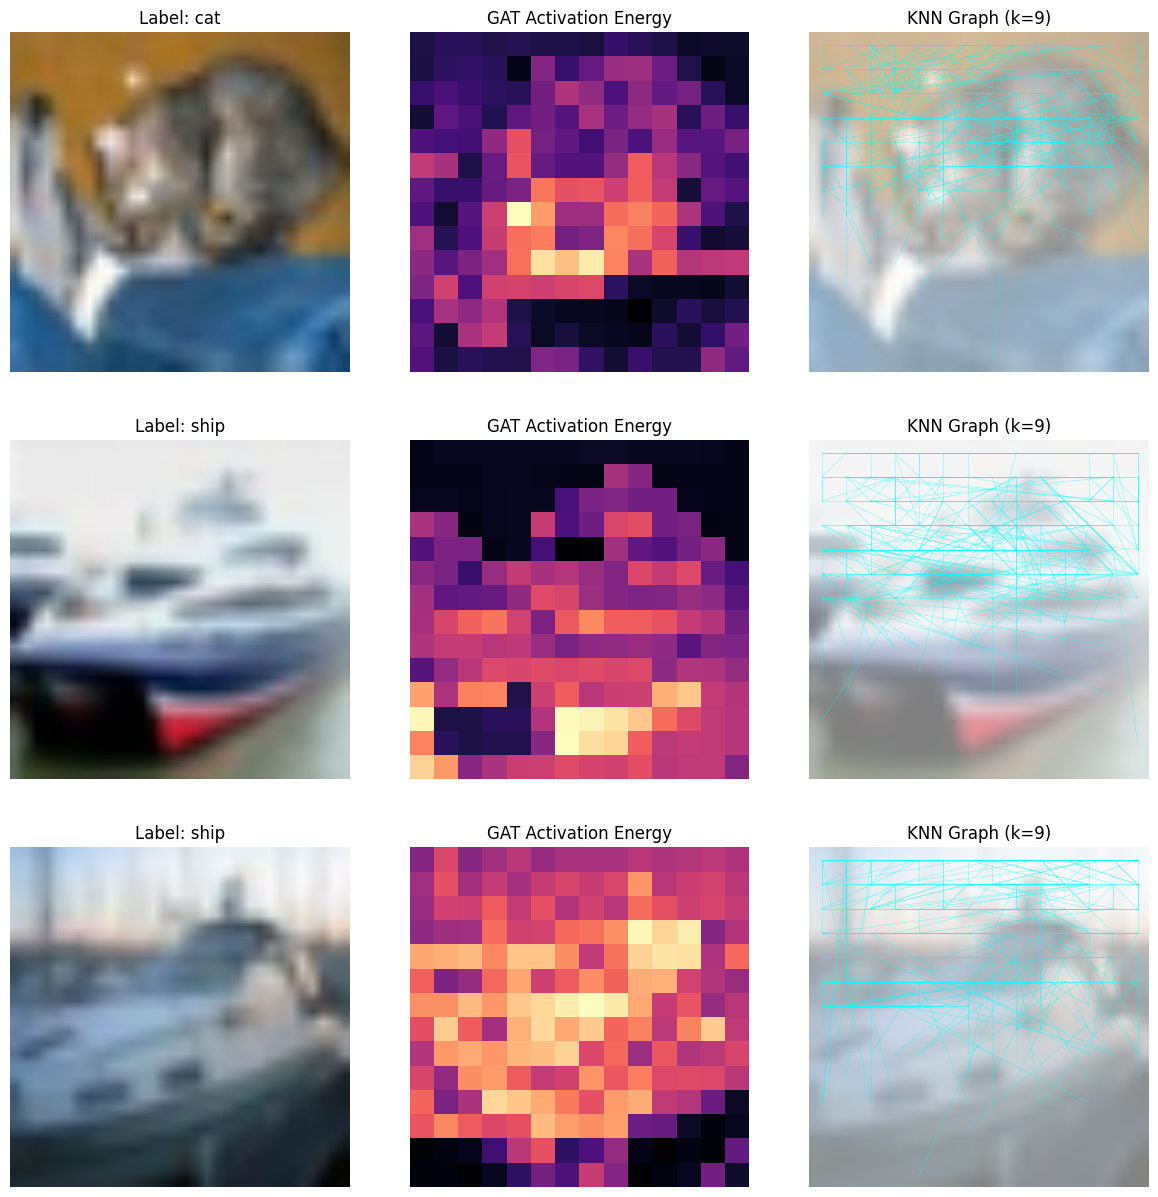

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
from torch_geometric.nn import knn_graph

def unnormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(tensor.device)
    img = tensor * std + mean
    return img.clamp(0, 1)

def visualize_activations(model, loader, k=9, num_samples=3):
    print(f"\n🎨 Generating GAT Activation Heatmaps...")
    model.eval()
    
    try:
        batch_data = next(iter(loader))
        if isinstance(batch_data, list):
            images, labels = batch_data[0].to(device), batch_data[1]
        else:
            images = batch_data.to(device)
            labels = None
    except Exception as e:
        print(f"Error: {e}")
        return

    with torch.no_grad():
        if hasattr(model, 'vit'):
            x = model.vit.conv_proj(images)
            x = x.flatten(2).transpose(1, 2)
            n = x.shape[0]
            batch_class_token = model.vit.class_token.expand(n, -1, -1)
            x = torch.cat([batch_class_token, x], dim=1)
            x = x + model.vit.encoder.pos_embedding
            # Need to loop depth manually for consistency with forward
            for i in range(model.depth):
                x = model.vit.encoder.layers[i](x)
            x = model.vit.encoder.ln(x)
            x = x[:, 1:] 
        
        B, N, C = x.shape
        x_flat = x.reshape(-1, C)
        batch_vec = torch.arange(B, device=images.device).repeat_interleave(N)
        edge_index = knn_graph(x_flat, k=k, batch=batch_vec, loop=True)
        
        # --- GAT Layers Manual Run ---
        h = model.conv1(x_flat, edge_index)
        if hasattr(model, 'bn1'): h = model.bn1(h)
        h = torch.relu(h)
        
        h = model.conv2(h, edge_index)
        if hasattr(model, 'bn2'): h = model.bn2(h)
        h = torch.relu(h)
        
        final_features = h 

    images = unnormalize(images).cpu()
    edge_index = edge_index.cpu()
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    plt.subplots_adjust(wspace=0.1, hspace=0.2)
    if num_samples == 1: axes = [axes]

    for i in range(num_samples):
        # Image
        ax_img = axes[i][0]
        ax_img.imshow(images[i].permute(1, 2, 0))
        title = testset.classes[labels[i]] if labels is not None and hasattr(testset, 'classes') else "Input"
        ax_img.set_title(f"Label: {title}")
        ax_img.axis('off')

        # Activation Heatmap
        node_start = i * N
        node_end = (i + 1) * N
        img_feats = final_features[node_start:node_end]
        activation_map = img_feats.norm(dim=1) 
        
        grid_dim = int(np.sqrt(N)) 
        heatmap = activation_map.reshape(grid_dim, grid_dim).cpu().numpy()
        
        ax_map = axes[i][1]
        sns.heatmap(heatmap, cmap='magma', ax=ax_map, cbar=False, square=True)
        ax_map.set_title("GAT Activation Energy")
        ax_map.axis('off')

        # Graph Overlay
        ax_graph = axes[i][2]
        ax_graph.imshow(images[i].permute(1, 2, 0), alpha=0.5)
        
        relevant_edges = edge_index[:, (edge_index[0] >= node_start) & (edge_index[0] < node_end)]
        relevant_edges = relevant_edges - node_start
        
        step = 224 / grid_dim
        coords = [(c * step + step/2, r * step + step/2) for r in range(grid_dim) for c in range(grid_dim)]
        
        subset_edges = relevant_edges[:, ::2] 
        for e in range(min(400, subset_edges.shape[1])):
            src, dst = subset_edges[0, e], subset_edges[1, e]
            ax_graph.plot([coords[src][0], coords[dst][0]], [coords[src][1], coords[dst][1]], 
                          color='cyan', linewidth=0.5, alpha=0.4)
            
        ax_graph.set_title(f"KNN Graph (k={k})")
        ax_graph.axis('off')

    plt.show()

# Run it
visualize_activations(model, testloader, k=9, num_samples=3)